## Understanding the Receiver Operating Characteristic (ROC) Curve and AUC

### Step 1: The Core Metrics of ROC

To build an ROC curve, we must discard Precision and focus on two different metrics that look purely at the actual rows of our reality: True Positive Rate (TPR) and False Positive Rate (FPR).

#### 1. True Positive Rate (TPR) / Sensitivity

This is mathematically identical to Recall. Out of all the actual positive cases in the real world (e.g., actual sick patients), how many did your model catch?

$$\text{TPR} = \frac{\text{True Positives}}{\text{Actual Positives}} = \frac{TP}{TP + FN}$$

**Goal**: We want this to be 1.0 (100% hit rate).

#### 2. False Positive Rate (FPR)

Out of all the actual negative cases in the real world (e.g., perfectly healthy people), how many did your model accidentally trigger a false alarm on?

$$\text{FPR} = \frac{\text{False Positives}}{\text{Actual Negatives}} = \frac{FP}{TN + FP}$$

**Goal**: We want this to be 0.0 (Zero false alarms).

### Step 2: Building the ROC Curve

ROC stands for Receiver Operating Characteristic (a name inherited from radar engineers in World War II trying to separate enemy planes from bird background noise).

The curve is a 2D graph where:
*   The Y-axis plots the TPR (Success rate).
*   The X-axis plots the FPR (False alarm rate).

#### The Threshold Sweep:

To plot the curve, a computer takes your Logistic Regression model and sweeps the classification threshold slider from 1.0 down to 0.0, calculating TPR and FPR at every step.

###### At Threshold = 1.0:

The model is exceptionally strict. It classifies nobody as positive.

*   $\text{TP} = 0$, $\text{FP} = 0$.
*   Therefore, $\text{TPR} = 0$ and $\text{FPR} = 0$.

**Plot point starts at $(0,0)$ in the bottom left corner.**

##### As Threshold drops (e.g., 0.7 $\to$ 0.5 $\to$ 0.3):

The model relaxes its criteria. It starts catching sick patients ($\text{TPR}$ goes up), but it also starts letting a few false alarms slip through ($\text{FPR}$ goes right).

##### At Threshold = 0.0:

The model classifies everyone as positive.

*   Everyone is caught, so $\text{FN} = 0$ ($\text{TPR} = 1$).
*   But everyone healthy is flagged as a false alarm, so $\text{TN} = 0$ ($\text{FPR} = 1$).

**Plot point ends at $(1,1)$ in the top right corner.**

#### Characteristics of a Great Model

A great model climbs vertically toward the top-left corner $(0,1)$ instantly—meaning it hits a 100% true positive rate while keeping false alarms at zero—before traveling to the top right.

### Step 3: What is the AUC (Area Under the Curve)?

The AUC is the total 2D area beneath that plotted ROC curve line. Since the graph is a $1 \times 1$ square, the maximum possible area is exactly 1.0.

#### The AUC Score Scale:

*   **$\text{AUC} = 0.5$ (The Random Line)**: This forms a diagonal line from $(0,0)$ to $(1,1)$. It means your model has zero predictive capability and is doing nothing better than flipping a random coin.

*   **$\text{AUC} = 1.0$ (The Perfect Model)**: The line travels straight up to $(0,1)$ and straight across to $(1,1)$. It completely separates the two classes without a single error.

*   **$\text{AUC} > 0.8$**: Generally considered an excellent production-grade classifier.

#### The Deep Definition of AUC:

If you take one random positive sample and one random negative sample from your dataset and hand them to your model, the AUC is the exact probability that the model will score the positive sample higher than the negative sample. It is a pure metric of the model's structural ability to rank order risk, completely independent of whatever threshold you choose.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# generate data
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.7, 0.3], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# CRITICAL: We need the raw continuous probabilities for Class 1, NOT the hard predictions
y_probs = model.predict_proba(X_test)[:, 1]

In [3]:
# calculate roc and auc values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

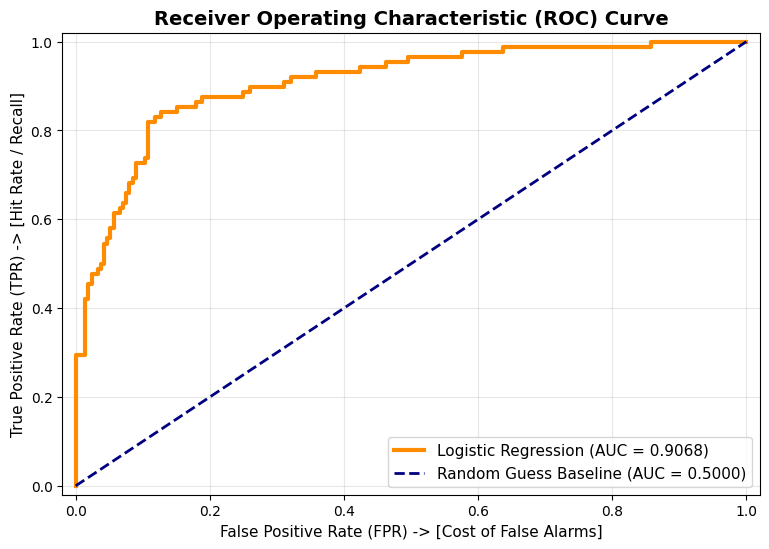

SAMPLE OF THE THRESHOLD SWEEP PROFILE
Threshold: inf | FPR: 0.0000 | TPR: 0.0000
Threshold: 0.7193 | FPR: 0.0519 | TPR: 0.5568
Threshold: 0.3874 | FPR: 0.1085 | TPR: 0.7386
Threshold: 0.1013 | FPR: 0.3113 | TPR: 0.9091
Threshold: 0.0000 | FPR: 1.0000 | TPR: 1.0000


In [4]:
# visualization
plt.figure(figsize=(9, 6))

# Plot the custom model's curve
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Logistic Regression (AUC = {auc_score:.4f})')

# Plot the random guess baseline (Coin flip)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess Baseline (AUC = 0.5000)')

# Visual touch-ups
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR) -> [Cost of False Alarms]', fontsize=11)
plt.ylabel('True Positive Rate (TPR) -> [Hit Rate / Recall]', fontsize=11)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Print out a sample of the threshold sweep mechanics
print("==================================================")
print("SAMPLE OF THE THRESHOLD SWEEP PROFILE")
print("==================================================")
# Print out indices at intervals to see the transition
for idx in [0, len(thresholds)//4, len(thresholds)//2, 3*len(thresholds)//4, len(thresholds)-1]:
    print(f"Threshold: {thresholds[idx]:.4f} | FPR: {fpr[idx]:.4f} | TPR: {tpr[idx]:.4f}")